# K-Means Parallèle sur CPU

**Projet** : Parallélisation du K-Means sur CPU avec OpenMP  

## Objectif

Comparer deux implémentations du K-Means :
- **Version 1** : NumPy séquentiel (baseline)  
- **Version 2** : C++ + OpenMP (parallèle)


In [1]:
import sys, os
sys.path.insert(0, "../src")

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.metrics import adjusted_rand_score

# Pour la reproductibilité
np.random.seed(42)


## 1. Données synthétiques

On génère des données avec `make_blobs` : des clusters bien séparés pour valider la correction, puis des clusters plus denses pour le benchmark.

Données validation : (300, 2)
Données benchmark  : (50000, 10)


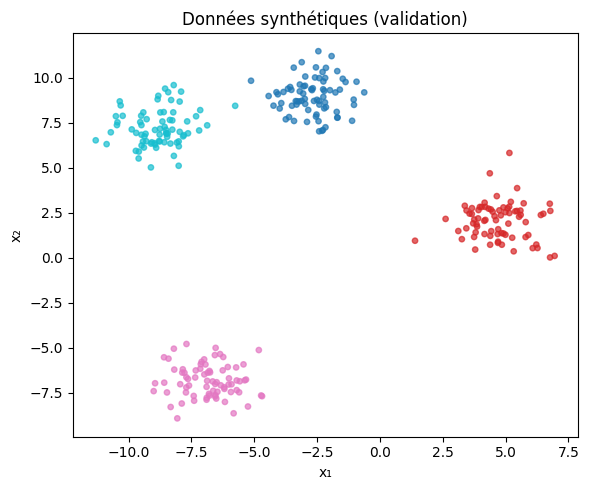

In [2]:
# Données de validation 
X_small, y_true_small = make_blobs(
    n_samples=300, centers=4, n_features=2,
    random_state=42, cluster_std=1.0
)
X_small = X_small.astype(np.float32)

# Données de benchmark 
X_bench, y_true_bench = make_blobs(
    n_samples=50_000, centers=8, n_features=10,
    random_state=42, cluster_std=2.0
)
X_bench = X_bench.astype(np.float32)

print(f"Données validation : {X_small.shape}")
print(f"Données benchmark  : {X_bench.shape}")

# Visualiser les données de validation
fig, ax = plt.subplots(figsize=(6, 5))
scatter = ax.scatter(X_small[:, 0], X_small[:, 1],
                     c=y_true_small, cmap='tab10', s=15, alpha=0.7)
ax.set_title("Données synthétiques (validation)")
ax.set_xlabel("x₁")
ax.set_ylabel("x₂")
plt.tight_layout()
plt.show()


## 2. Version NumPy

Implémentation vectorisée inspirée de l'approche **GroupBy → Aggregate** de Terrell (2017) :
- `assign_numpy` : broadcasting NumPy pour calculer toutes les distances en une opération
- `update_numpy` : masque booléen pour grouper les points par cluster, puis moyenne

Cette version est **séquentielle** 

In [3]:
from kmeans_numpy import kmeans_numpy, assign_numpy, update_numpy

import inspect

In [5]:
# Test sur données de validation
centroids_np, labels_np, n_iter_np = kmeans_numpy(
    X_small, K=4, seed=42, verbose=True
)
print(f"\nConvergence en {n_iter_np} itérations")
print(f"Centroïdes finaux :\n{centroids_np}")

  iter   1 | shift = 9.583846
  iter   2 | shift = 3.723595
  iter   3 | shift = 0.205104
  iter   4 | shift = 0.092973
  iter   5 | shift = 0.049953
  iter   6 | shift = 0.042594
  iter   7 | shift = 0.000000
  Convergence à l'itération 7

Convergence en 7 itérations
Centroïdes finaux :
[[ 4.221067   2.4764287]
 [-6.8323517 -6.830457 ]
 [ 5.506769   1.3523804]
 [-5.750602   8.084988 ]]


## 3. Version C++ + OpenMP

La phase **assignment** est parallélisée avec `#pragma omp parallel for schedule(static)` :
- Chaque thread traite un sous-ensemble des n points
- Aucune synchronisation nécessaire (chaque point est indépendant)
- `schedule(static)` : optimal car chaque point fait exactement K×d opérations (charge uniforme)

La phase **update** reste séquentielle

In [6]:
from kmeans_parallel import kmeans_parallel

import inspect, sys
sys.path.insert(0, "../src/kmeans_cpp/build")
import kmeans_cpp


In [7]:
# Test sur données de validation
centroids_par, labels_par, n_iter_par = kmeans_parallel(
    X_small, K=4, seed=42, verbose=True
)
print(f"\nConvergence en {n_iter_par} itérations")
print(f"Centroïdes finaux :\n{centroids_par}")

  iter   1 | shift = 9.583846
  iter   2 | shift = 3.723595
  iter   3 | shift = 0.205104
  iter   4 | shift = 0.092973
  iter   5 | shift = 0.049953
  iter   6 | shift = 0.042594
  iter   7 | shift = 0.000000
  Convergence à l'itération 7

Convergence en 7 itérations
Centroïdes finaux :
[[ 4.221067   2.4764287]
 [-6.8323517 -6.830457 ]
 [ 5.506769   1.3523804]
 [-5.750602   8.084988 ]]


## 4. Validation : les deux versions donnent-elles le même résultat ?

On compare les labels via le **Adjusted Rand Index** (ARI = 1.0 si identique) et la différence maximale entre centroïdes.

Adjusted Rand Index : 1.0000 (1.0 = identique)
Différence max centroïdes : 0.00e+00


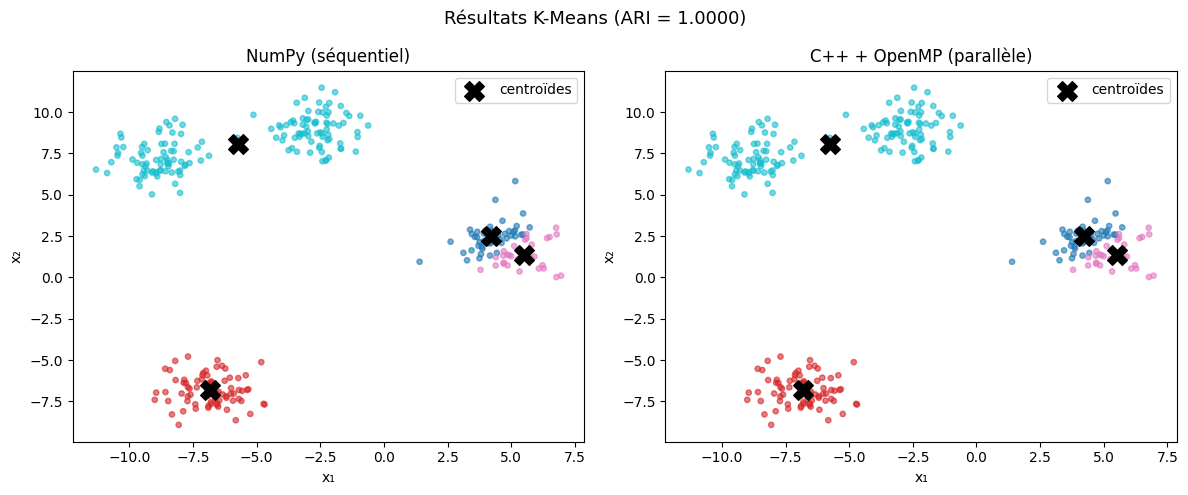

In [8]:
# ARI entre les deux versions
ari = adjusted_rand_score(labels_np, labels_par)
print(f"Adjusted Rand Index : {ari:.4f} (1.0 = identique)")

# Différence entre centroïdes (après tri pour aligner les clusters)
idx_np  = np.argsort(np.linalg.norm(centroids_np,  axis=1))
idx_par = np.argsort(np.linalg.norm(centroids_par, axis=1))
diff = np.abs(centroids_np[idx_np] - centroids_par[idx_par]).max()
print(f"Différence max centroïdes : {diff:.2e}")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, labels, cents, title in [
    (axes[0], labels_np,  centroids_np,  "NumPy (séquentiel)"),
    (axes[1], labels_par, centroids_par, "C++ + OpenMP (parallèle)"),
]:
    ax.scatter(X_small[:, 0], X_small[:, 1],
               c=labels, cmap='tab10', s=15, alpha=0.6)
    ax.scatter(cents[:, 0], cents[:, 1],
               c='black', marker='X', s=200, zorder=5, label='centroïdes')
    ax.set_title(title)
    ax.set_xlabel("x₁"); ax.set_ylabel("x₂")
    ax.legend()

plt.suptitle(f"Résultats K-Means (ARI = {ari:.4f})", fontsize=13)
plt.tight_layout()
plt.show()

---
## Further work: parallélisation de la phase UPDATE

### Pourquoi ?

Dans la version précédente (v1), seule la phase **assignment** était parallèle. La phase **update** (recalcul des centroïdes) restait séquentielle, justifiée par le fait qu'elle représente moins de 0.5% du temps total (Lavenier 2001).

Mais pour des cas où `K` et `d` sont grands (ex. K=50, d=100), la phase update peut devenir non négligeable. On la parallélise ici via la stratégie des **buffers locaux par thread**
### Stratégie

```
Thread 0 : local_sum_0[K×d], local_count_0[K]  → accumule points 0..n/4
Thread 1 : local_sum_1[K×d], local_count_1[K]  → accumule points n/4..n/2
Thread 2 : local_sum_2[K×d], local_count_2[K]  → accumule points n/2..3n/4
Thread 3 : local_sum_3[K×d], local_count_3[K]  → accumule points 3n/4..n

#pragma omp critical (fusion, courte) :
    centroids += local_sum_0 + local_sum_1 + local_sum_2 + local_sum_3
```

**Pas de race condition** : chaque thread écrit uniquement dans son buffer privé. La section `critical` ne couvre que la fusion finale, qui est O(T × K × d) avec T = nb threads.


In [ ]:
from kmeans_parallel_v2 import kmeans_parallel_v2
import inspect

In [ ]:
# Validation : v2 donne le même résultat que numpy et v1
from sklearn.metrics import adjusted_rand_score

c_v2, l_v2, it_v2 = kmeans_parallel_v2(X_small, K=4, seed=42, verbose=True)

print(f"\nConvergence en {it_v2} itérations")
print(f"ARI numpy vs v2 : {adjusted_rand_score(labels_np, l_v2):.4f}")

idx_np = np.argsort(np.linalg.norm(centroids_np, axis=1))
idx_v2 = np.argsort(np.linalg.norm(c_v2, axis=1))
diff = np.abs(centroids_np[idx_np] - c_v2[idx_v2]).max()
print(f"Diff max centroïdes : {diff:.2e}  (non-associativité fp32 attendue)")

  iter   1 | shift = 9.583845
  iter   2 | shift = 3.723595
  iter   3 | shift = 0.205103
  iter   4 | shift = 0.092973
  iter   5 | shift = 0.049953
  iter   6 | shift = 0.042594
  iter   7 | shift = 0.000000
  Convergence à l'itération 7

Convergence en 7 itérations
ARI numpy vs v2 : 1.0000
Diff max centroïdes : 4.77e-07  (non-associativité fp32 attendue)
